In [1]:
import polars as pl
import uproot
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from matplotlib import dates as mdates
import numpy as np

# old appraoch
```py
root_file = uproot.open("data/archive/environment_data-08-03-2026-00_00_21.root")
date_1970 = datetime.datetime(1970, 1, 1,1)
data = (
    pl.from_pandas(root_file["Vacuum"].arrays(['__timestamp_s','__timestamp_ns',"CC-Elena"],library='pd'))
    # .with_columns(pl.from_epoch("__timestamp_s", time_unit="ms"))
    .with_columns(date=pl.lit(date_1970) + pl.duration(seconds=pl.col("__timestamp_s")+pl.col("__timestamp_ns")/1e9))
)
print(data)
```


In [30]:
# new approach (using directly data from the plot on Enviro)
vaccum_sensors = ["ELENA","HH","TL","OVC","UHV","A-Sun","Moire","Line-75"]
new_columns = list(np.array([[f"date_{sensor}",f"{sensor}"] for sensor in vaccum_sensors]).flatten())
print(new_columns)
data = pl.read_csv("data/Environment Manager - history (High Vacuum).dat",separator="\t",has_header=False,new_columns=new_columns).with_columns(pl.from_epoch(pl.selectors.starts_with("date")-2082844800+3600))
print(data)

['date_ELENA', 'ELENA', 'date_HH', 'HH', 'date_TL', 'TL', 'date_OVC', 'OVC', 'date_UHV', 'UHV', 'date_A-Sun', 'A-Sun', 'date_Moire', 'Moire', 'date_Line-75', 'Line-75']
shape: (44_000, 16)
┌────────────┬───────────┬────────────┬───────────┬───┬────────────┬───────┬───────────┬───────────┐
│ date_ELENA ┆ ELENA     ┆ date_HH    ┆ HH        ┆ … ┆ date_Moire ┆ Moire ┆ date_Line ┆ Line-75   │
│ ---        ┆ ---       ┆ ---        ┆ ---       ┆   ┆ ---        ┆ ---   ┆ -75       ┆ ---       │
│ datetime[μ ┆ f64       ┆ datetime[μ ┆ f64       ┆   ┆ datetime[μ ┆ f64   ┆ ---       ┆ f64       │
│ s]         ┆           ┆ s]         ┆           ┆   ┆ s]         ┆       ┆ datetime[ ┆           │
│            ┆           ┆            ┆           ┆   ┆            ┆       ┆ μs]       ┆           │
╞════════════╪═══════════╪════════════╪═══════════╪═══╪════════════╪═══════╪═══════════╪═══════════╡
│ 2026-03-16 ┆ 1.0000e-9 ┆ 2026-03-16 ┆ 2.3000e-8 ┆ … ┆ 2026-03-16 ┆ 0.02  ┆ 2026-03-1 ┆ 0.02      │
│ 1

In [39]:
data.write_csv("data/valve_test_pressures.csv")

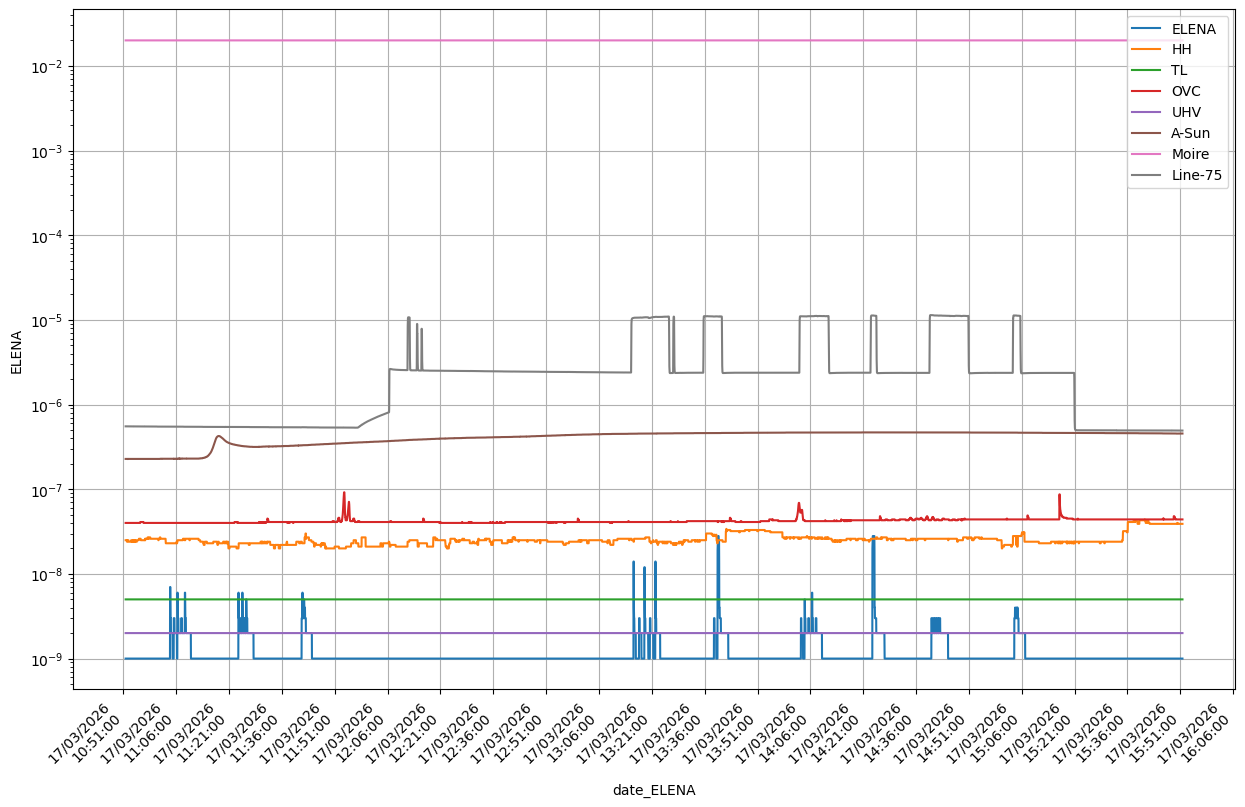

In [38]:
fig,ax = plt.subplots(figsize=(15,10))
for sensor in vaccum_sensors:
    plot = sns.lineplot(data.filter(pl.col("date_ELENA")>pl.col("date_ELENA").max()-datetime.timedelta(seconds=5*60*60)),x=f"date_{sensor}",y=f"{sensor}",label=f"{sensor}",ax=ax)
    plot.set_yscale("log")
# plot.xaxis.set_minor_locator(mdates.SecondLocator(interval=30))
plot.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
plot.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y\n%H:%M:%S'))
plot.grid(True)
# plt.xticks(rotation=45, ha='right')
plot.get_figure().autofmt_xdate(rotation=45)

======= 90 s =======
shape: (10, 1)
┌────────────────┐
│ date           │
│ ---            │
│ duration[μs]   │
╞════════════════╡
│ null           │
│ 3s 8867µs      │
│ 1m 30s 11316µs │
│ 3s 8290µs      │
│ 1m 30s 9474µs  │
│ 3s 15296µs     │
│ 1m 30s 3738µs  │
│ 3s 1240µs      │
│ 1m 30s 6797µs  │
│ 3s 13475µs     │
└────────────────┘
ionsource window size:0:18:15.092888
background window size:0:18:15.078493
======= 60 s =======
shape: (10, 1)
┌──────────────┐
│ date         │
│ ---          │
│ duration[μs] │
╞══════════════╡
│ null         │
│ 3s 14429µs   │
│ 1m 9288µs    │
│ 3s 15657µs   │
│ 1m 14851µs   │
│ 3s 3645µs    │
│ 1m 4261µs    │
│ 3s 454µs     │
│ 1m 15778µs   │
│ 3s 14650µs   │
└──────────────┘
ionsource window size:0:16:15.057986
background window size:0:16:15.093013
======= 30 s =======
shape: (10, 1)
┌──────────────┐
│ date         │
│ ---          │
│ duration[μs] │
╞══════════════╡
│ null         │
│ 3s 13161µs   │
│ 30s 1577µs   │
│ 3s 4796µs    │
│ 30s 14939µs

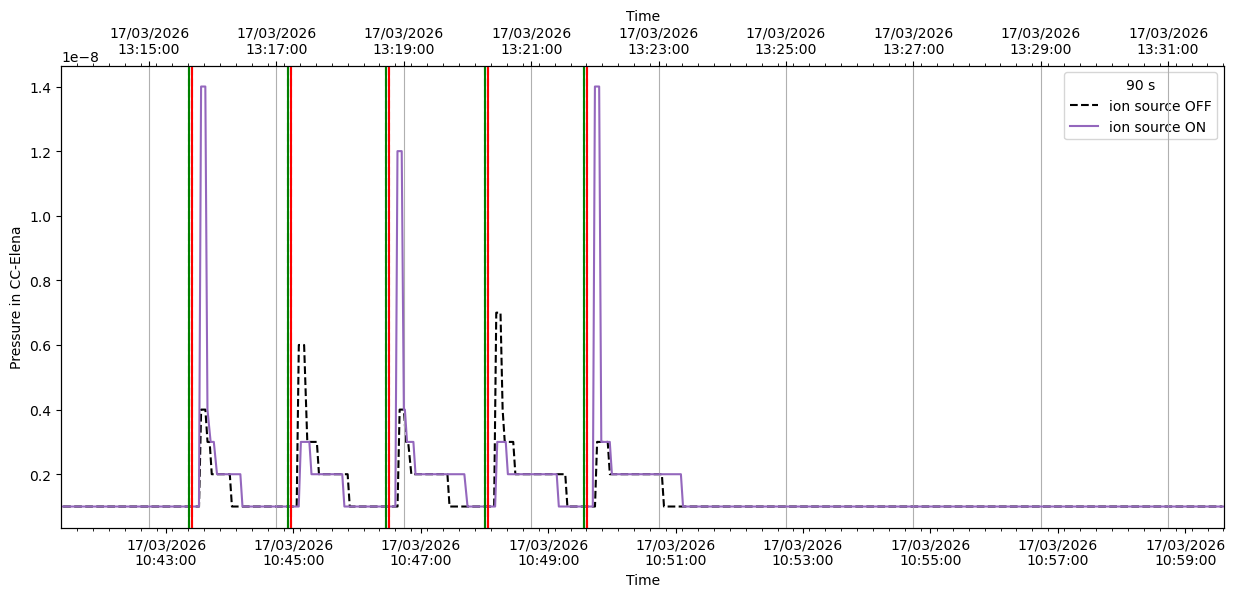

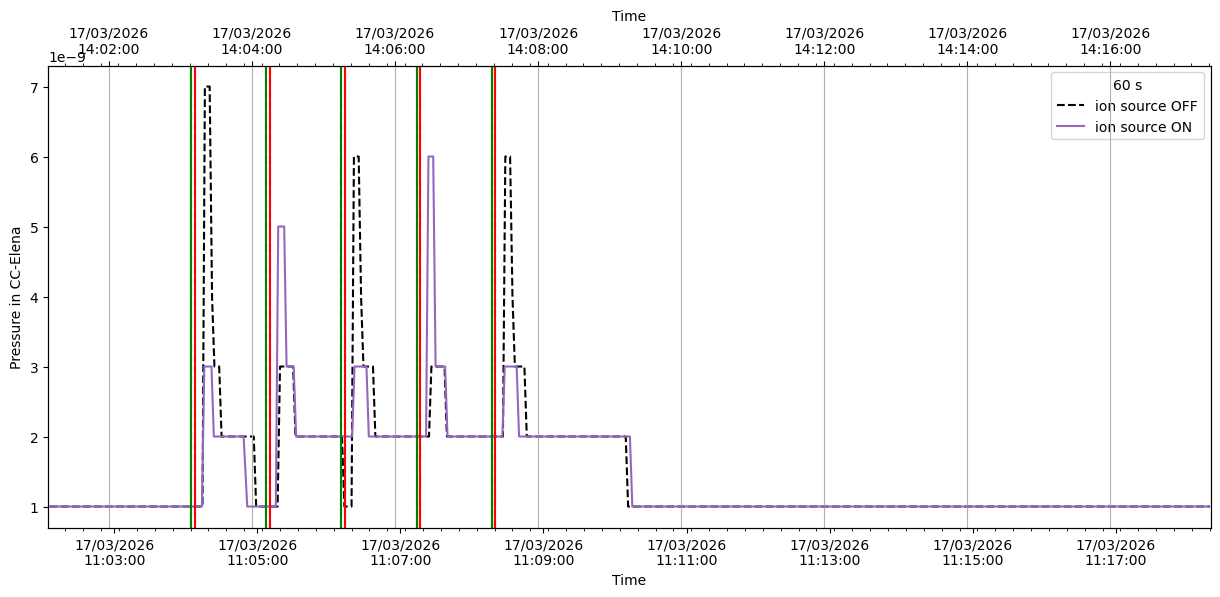

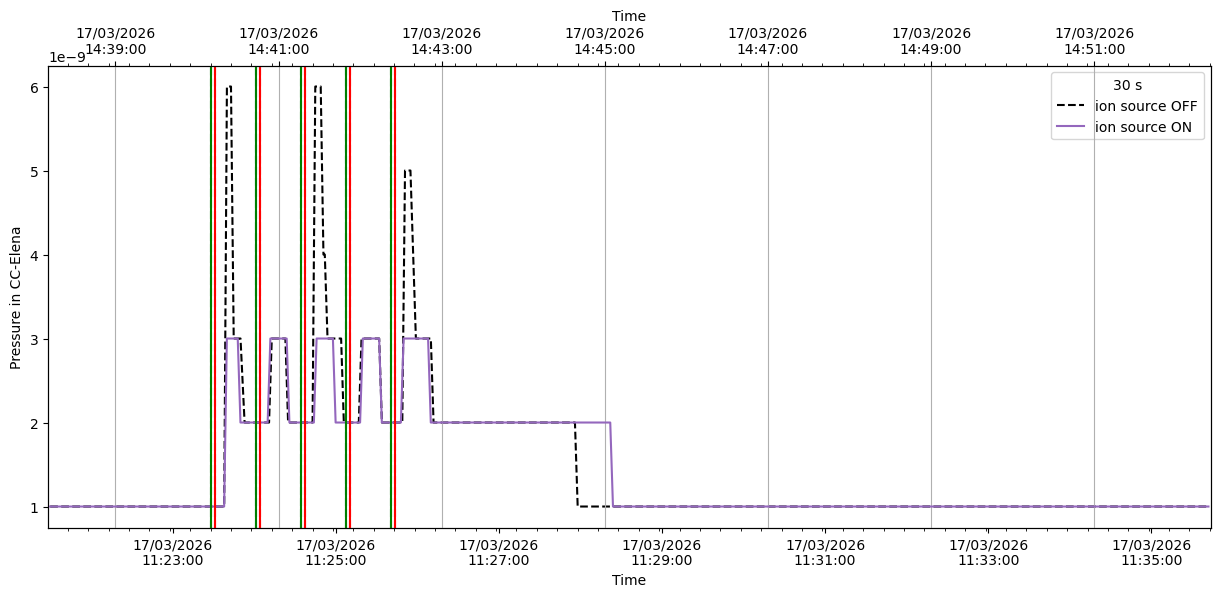

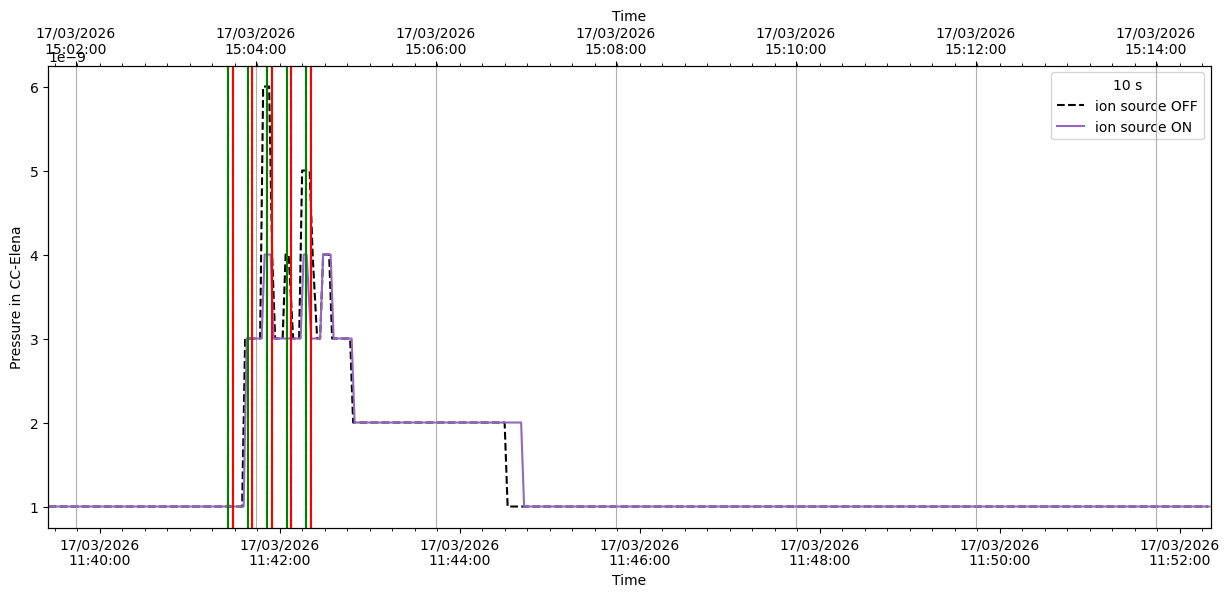

In [34]:
close_durations = [90,60,30,10] # s
pre_delay = 2*60 # s
post_delay = 10*60 # s

for close_duration in close_durations:
    print(f"======= {close_duration} s =======")
    fig,ax = plt.subplots(figsize=(15,6))
    
    valve_state_bcg = pl.read_csv(f"data/borealis_valve_test_background_{close_duration}s.dat",new_columns=["date","state"],has_header=False,try_parse_dates=True,comment_prefix="#")
    print(valve_state_bcg.select(pl.col("date").diff(1)))
    starttime_bcg = valve_state_bcg.select(pl.col("date").first()).item() - datetime.timedelta(seconds=pre_delay)
    endtime_bcg = valve_state_bcg.select(pl.col("date").last()).item() + datetime.timedelta(seconds=post_delay)
    data_bcg = data.filter(pl.col("date_ELENA").is_between(starttime_bcg,endtime_bcg))
    
    ax.plot(data_bcg['date_ELENA'],data_bcg['ELENA'],linestyle='--',color='black',label='ion source OFF')
    for time,state in zip(pl.Series(valve_state_bcg["date"]).to_list(),pl.Series(valve_state_bcg["state"]).to_list()):
        ax.axvline(time,color = 'green' if state=='open' else 'red',linestyle='--')
    
    ax.set_ylabel("Pressure in CC-Elena")
    ax.set_xlabel("Time")
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=15))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y\n%H:%M:%S'))
    ax.set_xlim(starttime_bcg,endtime_bcg)
    ax.grid(False)
    
    
    ax2 = ax.twiny()
    
    valve_state_ionsource = pl.read_csv(f"data/borealis_valve_test_ionsource_{close_duration}s.dat",new_columns=["date","state"],has_header=False,try_parse_dates=True,comment_prefix="#")
    starttime_ionsource = valve_state_ionsource.select(pl.col("date").first()).item() - datetime.timedelta(seconds=pre_delay)
    endtime_ionsource = valve_state_ionsource.select(pl.col("date").last()).item() + datetime.timedelta(seconds=post_delay)
    data_ionsource = data.filter(pl.col("date_ELENA").is_between(starttime_ionsource,endtime_ionsource))
    
    ax2.plot(data_ionsource['date_ELENA'],data_ionsource['ELENA'],color='tab:purple',label='ion source ON')
    for time,state in zip(pl.Series(valve_state_ionsource["date"]).to_list(),pl.Series(valve_state_ionsource["state"]).to_list()):
        ax2.axvline(time,color = 'green' if state=='open' else 'red')
    
    ax2.set_xlabel("Time")
    ax2.xaxis.set_minor_locator(mdates.SecondLocator(interval=15))
    ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y\n%H:%M:%S'))
    ax2.set_xlim(starttime_ionsource,endtime_ionsource)
    ax2.grid(True)

    ax.legend(handles=ax.get_legend_handles_labels()[0]+ax2.get_legend_handles_labels()[0],title=f"{close_duration} s")
    
    print(f"ionsource window size:{endtime_ionsource-starttime_ionsource}")
    print(f"background window size:{endtime_bcg-starttime_bcg}")
        
plt.show()